In [1]:
import os
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID" #same order as nvidia-smi
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
import pyterrier as pt
import pyterrier_alpha as pta
from pathlib import Path
import pandas as pd

DATASETS = {
    'dev1': {
        'queries': '../queries/dev1/dev1-2025-queries.jsonl',
        'qrels': '../queries/dev1/dev1-2025-qrel.txt'
    },
    'dev2': {
        'queries': '../queries/dev2/dev2-2025-queries.jsonl',
        'qrels': '../queries/dev2/dev2-2025-qrel.txt'
    },
    'dev3': {
        'queries': '../queries/dev3/dev3-2025-queries.jsonl',
        'qrels': '../queries/dev3/dev3-2025-qrel.txt',
    },
    'test-2025': {
        'queries': '../queries/test-2025/test-2025-queries.jsonl',
        'qrels': '../queries/test-2025/test-2025-qrel.txt',
    },
    'train-2025': {
        'queries': '../queries/train-2025/train-2025-queries.jsonl',
        'qrels': '../queries/train-2025/train-2025-qrel.txt',
    },
    'train-2026': {
        'queries': '../queries/2026/train/queries-train-en.jsonl',
        'qrels': '../queries/2026/train/qrels-train-en.txt',
    },
    'dev-2026': {
        'queries': '../queries/2026/dev/queries-dev-en.jsonl',
        'qrels': '../queries/2026/dev/qrels-dev-en.txt'
    },
    'sft-train': {
        'queries': '../queries/sft-train/queries.jsonl',
        'qrels': '../queries/sft-train/qrels.txt'
    }
}

#DATASETS_TO_TEST = ['dev1', 'dev2', 'dev3', 'test-2025', 'train-2025']
DATASETS_TO_TEST = ['test-2025']

def get_result_dirs(base_dir: Path):
    return [
        { 'name': 'bm25', 'dir': base_dir/'bm25', 'variations': None },
        #{ 'name': 'dense-small', 'dir': base_dir/'dense-harrier-small', 'variations': ['max', 'top3'] },
        { 'name': 'dense-medium', 'dir': base_dir/'dense-harrier-medium', 'variations': ['max', 'top3'] },
        { 'name': 'splade', 'dir': base_dir/'splade-passage', 'variations': ['max', 'top3'] },
    ]

In [2]:
class ExperimentResults:
    def __init__(self, experiments, datasets, k=60):
        self.k = k
        self.dt2files = self._infer_result_files(experiments, datasets)
        self.qrels, self.queries = self._load_qrels_queries(datasets)
        self.dt2dfs = self._load_trec_csv(self.dt2files)

    def _infer_result_files(self, experiments, datasets):
        'Take in result details, output files grouped by dataset'

        dt2files = { x: {} for x in datasets }
        for xp in experiments:
            files = [f for f in Path(xp['dir']).iterdir() if f.is_file()]

            for d in datasets:
                if xp['variations'] == None:
                    dt2files[d][xp['name']] = next((f for f in files if d in f.name))
                    continue
                for var in xp['variations']:
                    dt2files[d][xp['name'] + '-' + var] = next((f for f in files if d in f.name and var in f.name))

        return dt2files
    
    def _load_qrels_queries(self, datasets):
        dt2qrel = {}
        dt2queries = {}

        for dt in datasets:            
            #load qrels
            dt2qrel[dt] = pd.read_csv(DATASETS[dt]['qrels'], usecols=[0, 2, 3], names=['qid', 'docno', 'relevance'], header=None, sep=' ',
                                dtype={'qid': 'str', 'docno': 'str', 'relevance': 'int64'})
            
            #load queries
            dt2queries[dt] = pd.read_json(DATASETS[dt]['queries'], lines=True, dtype={'query_id': 'str', 'query': 'str'}).rename(columns={'query_id': 'qid'})

        return dt2qrel, dt2queries

    def _load_trec_csv(self, dt2files: dict):
        dt2df = { x: {} for x in dt2files.keys() }

        print(dt2files)
        for name, experiments in dt2files.items():
            for exp, file in experiments.items():
                dt2df[name][exp] = pd.read_csv(file, dtype={'qid': 'string'})

            #Also do rr fusion
            dt2df[name]['fused'] = pta.fusion.rr_fusion(*[pd.merge(self.queries[name], x, on='qid') for x in dt2df[name].values()], num_results=1000, k=self.k)
        
        return dt2df

    def aggregate_experiment_results(self, eval_metrics):
        dt2result = { x: {} for x in self.dt2dfs.keys() }

        for dataset, experiments in self.dt2dfs.items():
            dt2result[dataset] = pt.Experiment(
                [x for x in experiments.values()],
                self.queries[dataset],
                self.qrels[dataset],
                eval_metrics=eval_metrics,
                names=[x for x in experiments.keys()],
                highlight=True,
            )
        return dt2result

In [3]:
from ir_measures import *
AGGR_METRICS = [nDCG@10, nDCG@100, nDCG@1000, Success@1, Success@10, Success@100, Success@1000, MRR]

raw_results = ExperimentResults(get_result_dirs(Path('./raw-query')), DATASETS_TO_TEST)
agg_raw = raw_results.aggregate_experiment_results(AGGR_METRICS)

{'test-2025': {'bm25': PosixPath('raw-query/bm25/base-bm25-test-2025-run.csv'), 'dense-medium-max': PosixPath('raw-query/dense-harrier-medium/dense-harrier-medium-test-2025-run-max.csv'), 'dense-medium-top3': PosixPath('raw-query/dense-harrier-medium/dense-harrier-medium-test-2025-run-top3.csv'), 'splade-max': PosixPath('raw-query/splade-passage/splade-passage-test-2025-run-max.csv'), 'splade-top3': PosixPath('raw-query/splade-passage/splade-passage-test-2025-run-top3.csv')}}


In [4]:
agg_raw['test-2025']

,name,nDCG@10,nDCG@100,nDCG@1000,Success@1,Success@10,Success@100,Success@1000,RR
0,bm25,0.122330,0.147787,0.169970,0.078778,0.173633,0.303859,0.485531,0.111395
1,dense-medium-max,0.198183,0.240117,0.268504,0.107717,0.295820,0.498392,0.728296,0.176267
2,dense-medium-top3,0.166983,0.199747,0.237606,0.093248,0.257235,0.421222,0.741158,0.145873
3,splade-max,0.165448,0.204729,0.230212,0.098071,0.244373,0.442122,0.652733,0.148696
4,splade-top3,0.160087,0.191091,0.224714,0.099678,0.226688,0.381029,0.659164,0.145710
5,fused,0.220724,0.266743,0.293927,0.136656,0.313505,0.536977,0.757235,0.201211


In [5]:
baseline_rewrite_results = ExperimentResults(get_result_dirs(Path('./rewrite-baseline')), DATASETS_TO_TEST)
agg_baseline = baseline_rewrite_results.aggregate_experiment_results(AGGR_METRICS)

{'test-2025': {'bm25': PosixPath('rewrite-baseline/bm25/base-bm25-test-2025-run.csv'), 'dense-medium-max': PosixPath('rewrite-baseline/dense-harrier-medium/dense-harrier-medium-test-2025-run-max.csv'), 'dense-medium-top3': PosixPath('rewrite-baseline/dense-harrier-medium/dense-harrier-medium-test-2025-run-top3.csv'), 'splade-max': PosixPath('rewrite-baseline/splade-passage/splade-passage-test-2025-run-max.csv'), 'splade-top3': PosixPath('rewrite-baseline/splade-passage/splade-passage-test-2025-run-top3.csv')}}


In [6]:
agg_baseline['test-2025']

,name,nDCG@10,nDCG@100,nDCG@1000,Success@1,Success@10,Success@100,Success@1000,RR
0,bm25,0.170217,0.201642,0.225551,0.114148,0.236334,0.395498,0.590032,0.155743
1,dense-medium-max,0.232123,0.278712,0.301884,0.143087,0.334405,0.564309,0.752412,0.209385
2,dense-medium-top3,0.193658,0.228618,0.262046,0.109325,0.295820,0.464630,0.749196,0.169764
3,splade-max,0.163280,0.203950,0.232028,0.102894,0.231511,0.430868,0.662379,0.150609
4,splade-top3,0.139215,0.171136,0.209733,0.085209,0.205788,0.361736,0.675241,0.125874
5,fused,0.238248,0.286106,0.309784,0.146302,0.356913,0.594855,0.787781,0.211421


In [7]:
sft_rewrite_results = ExperimentResults(get_result_dirs(Path('./rewrite-sft')), DATASETS_TO_TEST)
agg_sft = sft_rewrite_results.aggregate_experiment_results(AGGR_METRICS)

{'test-2025': {'bm25': PosixPath('rewrite-sft/bm25/base-bm25-test-2025-run.csv'), 'dense-medium-max': PosixPath('rewrite-sft/dense-harrier-medium/dense-harrier-medium-test-2025-run-max.csv'), 'dense-medium-top3': PosixPath('rewrite-sft/dense-harrier-medium/dense-harrier-medium-test-2025-run-top3.csv'), 'splade-max': PosixPath('rewrite-sft/splade-passage/splade-passage-test-2025-run-max.csv'), 'splade-top3': PosixPath('rewrite-sft/splade-passage/splade-passage-test-2025-run-top3.csv')}}


In [8]:
agg_sft['test-2025']

,name,nDCG@10,nDCG@100,nDCG@1000,Success@1,Success@10,Success@100,Success@1000,RR
0,bm25,0.160886,0.195593,0.220996,0.093248,0.236334,0.411576,0.617363,0.143977
1,dense-medium-max,0.237315,0.284111,0.309374,0.151125,0.337621,0.565916,0.773312,0.215597
2,dense-medium-top3,0.194593,0.234333,0.269649,0.120579,0.279743,0.469453,0.770096,0.176844
3,splade-max,0.183060,0.225915,0.256010,0.117363,0.257235,0.469453,0.715434,0.168589
4,splade-top3,0.156398,0.192822,0.232006,0.096463,0.220257,0.400322,0.726688,0.143956
5,fused,0.244432,0.293338,0.315861,0.146302,0.374598,0.610932,0.794212,0.214963


In [101]:
agg_sft['dev-2026']

,name,nDCG@10,nDCG@100,nDCG@1000,Success@1,Success@10,Success@100,Success@1000,RR
0,dense-medium-max,0.264053,0.320385,0.347982,0.150,0.406,0.678,0.898,0.232282
1,dense-medium-top3,0.331895,0.385358,0.404509,0.196,0.496,0.752,0.902,0.292190
2,fused,0.318649,0.374030,0.392986,0.190,0.482,0.750,0.902,0.279824


In [9]:
sft_ast_results = ExperimentResults(get_result_dirs(Path('./rewrite-sft-ast')), DATASETS_TO_TEST, 1000)
agg_sft_ast = sft_ast_results.aggregate_experiment_results(AGGR_METRICS)

{'test-2025': {'bm25': PosixPath('rewrite-sft-ast/bm25/base-bm25-test-2025-run.csv'), 'dense-medium-max': PosixPath('rewrite-sft-ast/dense-harrier-medium/dense-harrier-medium-test-2025-run-max.csv'), 'dense-medium-top3': PosixPath('rewrite-sft-ast/dense-harrier-medium/dense-harrier-medium-test-2025-run-top3.csv'), 'splade-max': PosixPath('rewrite-sft-ast/splade-passage/splade-passage-test-2025-run-max.csv'), 'splade-top3': PosixPath('rewrite-sft-ast/splade-passage/splade-passage-test-2025-run-top3.csv')}}


In [10]:
agg_sft_ast['test-2025']

,name,nDCG@10,nDCG@100,nDCG@1000,Success@1,Success@10,Success@100,Success@1000,RR
0,bm25,0.132180,0.171475,0.196470,0.070740,0.204180,0.398714,0.604502,0.117731
1,dense-medium-max,0.275520,0.320738,0.344974,0.167203,0.401929,0.627010,0.824759,0.245307
2,dense-medium-top3,0.229695,0.267621,0.305379,0.144695,0.326367,0.509646,0.834405,0.207735
3,splade-max,0.219349,0.260977,0.289322,0.139871,0.311897,0.516077,0.749196,0.199236
4,splade-top3,0.182694,0.218841,0.255530,0.114148,0.260450,0.442122,0.749196,0.165792
5,fused,0.241528,0.297452,0.325263,0.146302,0.348875,0.620579,0.842444,0.219593


In [ ]:
agg_sft_ast['dev-2026']

,name,nDCG@10,nDCG@100,nDCG@1000,Success@1,Success@10,Success@100,Success@1000,RR
0,bm25,0.275661,0.321746,0.349178,0.186,0.380,0.608,0.832,0.252409
1,dense-medium-max,0.306841,0.367869,0.389131,0.176,0.456,0.750,0.920,0.272645
2,dense-medium-top3,0.376457,0.431358,0.447892,0.238,0.530,0.794,0.926,0.339502
3,splade-max,0.211610,0.270045,0.301714,0.122,0.330,0.610,0.870,0.187844
4,splade-top3,0.299319,0.347586,0.371564,0.186,0.438,0.676,0.868,0.266168
5,fused,0.483951,0.531614,0.543773,0.350,0.628,0.858,0.954,0.448063


In [11]:
simpo_results = ExperimentResults(get_result_dirs(Path('./rewrite-simpo-ast')), DATASETS_TO_TEST, 1000)
agg_simpo = simpo_results.aggregate_experiment_results(AGGR_METRICS)

{'test-2025': {'bm25': PosixPath('rewrite-simpo-ast/bm25/base-bm25-test-2025-run.csv'), 'dense-medium-max': PosixPath('rewrite-simpo-ast/dense-harrier-medium/dense-harrier-medium-test-2025-run-max.csv'), 'dense-medium-top3': PosixPath('rewrite-simpo-ast/dense-harrier-medium/dense-harrier-medium-test-2025-run-top3.csv'), 'splade-max': PosixPath('rewrite-simpo-ast/splade-passage/splade-passage-test-2025-run-max.csv'), 'splade-top3': PosixPath('rewrite-simpo-ast/splade-passage/splade-passage-test-2025-run-top3.csv')}}


In [12]:
agg_simpo['test-2025']

,name,nDCG@10,nDCG@100,nDCG@1000,Success@1,Success@10,Success@100,Success@1000,RR
0,bm25,0.215532,0.255628,0.278578,0.147910,0.295820,0.491961,0.681672,0.198706
1,dense-medium-max,0.317766,0.359946,0.386008,0.197749,0.456592,0.660772,0.869775,0.283528
2,dense-medium-top3,0.267970,0.299425,0.339449,0.176849,0.374598,0.528939,0.868167,0.241651
3,splade-max,0.282447,0.325527,0.350248,0.181672,0.390675,0.601286,0.800643,0.257243
4,splade-top3,0.223832,0.260400,0.296849,0.143087,0.315113,0.495177,0.797428,0.203012
5,fused,0.286035,0.340881,0.362700,0.180064,0.408360,0.683280,0.855305,0.258131


In [7]:
agg_simpo['dev-2026']

,name,nDCG@10,nDCG@100,nDCG@1000,Success@1,Success@10,Success@100,Success@1000,RR
0,bm25,0.482068,0.521980,0.538168,0.358,0.612,0.808,0.934,0.448554
1,dense-medium-max,0.457276,0.494825,0.514480,0.320,0.608,0.788,0.942,0.418010
2,dense-medium-top3,0.497699,0.543804,0.555109,0.368,0.634,0.856,0.946,0.463882
3,splade-max,0.376631,0.425114,0.447162,0.252,0.522,0.754,0.926,0.341784
4,splade-top3,0.439604,0.488248,0.505294,0.312,0.576,0.806,0.942,0.406649
5,fused,0.606815,0.635330,0.644036,0.448,0.770,0.906,0.974,0.560873


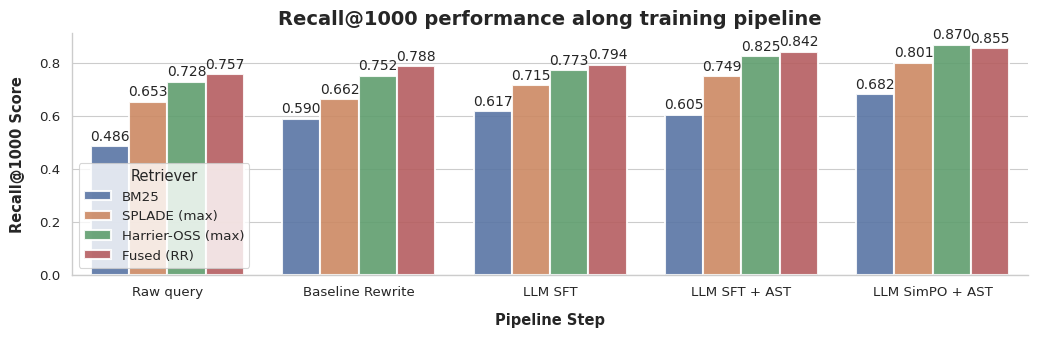

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

DATASET = 'test-2025'
METRICS = ['Success@1000']
STEPS   = ['Raw query', 'Baseline Rewrite', 'LLM SFT', 'LLM SFT + AST', 'LLM SimPO + AST']
STEP_DIRS = {
    'Raw query':      agg_raw,
    'Baseline Rewrite': agg_baseline,
    'LLM SFT':      agg_sft,
    'LLM SFT + AST':  agg_sft_ast,
    'LLM SimPO + AST':    agg_simpo,
}

# Map from retriever display name -> row label in the agg_* DataFrames
RETRIEVERS = {
    'BM25':           'bm25',
    'SPLADE (max)':   'splade-max',
    'Harrier-OSS (max)': 'dense-medium-max',
    'Fused (RR)':     'fused',
}

# Build long-form DataFrame: one row per (step, retriever) per metric
rows = []
for step, agg in STEP_DIRS.items():
    df = agg[DATASET].set_index('name')
    for display, key in RETRIEVERS.items():
        for metric in METRICS:
            rows.append({
                'step':      step,
                'retriever': display,
                'metric':    metric,
                'value':     df.loc[key, metric],
            })
long_df = pd.DataFrame(rows)

# Order the categorical axes
long_df['step']      = pd.Categorical(long_df['step'],      categories=STEPS,   ordered=True)
long_df['retriever'] = pd.Categorical(long_df['retriever'], categories=list(RETRIEVERS.keys()), ordered=True)
long_df['metric']    = pd.Categorical(long_df['metric'],    categories=METRICS, ordered=True)

# Plot: 1 row x 3 cols, one subplot per metric
sns.set_theme(style='whitegrid', context='paper', font_scale=1.1)
PALETTE = sns.color_palette('deep', n_colors=len(RETRIEVERS))

g = sns.catplot(
    data=long_df,
    kind='bar',
    x='step', y='value', hue='retriever',
    col='metric',
    order=STEPS,
    hue_order=list(RETRIEVERS.keys()),
    palette=PALETTE,
    height=3.5, aspect=3,
    errorbar=None,           # point estimates only; switch to 'sd' if you bootstrap
    legend_out=False,
    sharey=False,
    alpha=0.9,
    edgecolor="white", 
    linewidth=1.5
)

# Annotate bar values
for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=10, padding=2, rotation=0)
    ax.set_xlabel('Pipeline Step', fontweight='bold', labelpad=10)
    ax.set_ylabel('Recall@1000 Score', fontweight='bold', labelpad=10)
    ax.tick_params(axis='x')

g.set_titles('Recall@1000 performance along training pipeline', size=14, fontweight='bold')
g._legend.set_title('Retriever')
g._legend.set_frame_on(True)


plt.tight_layout()
plt.show()

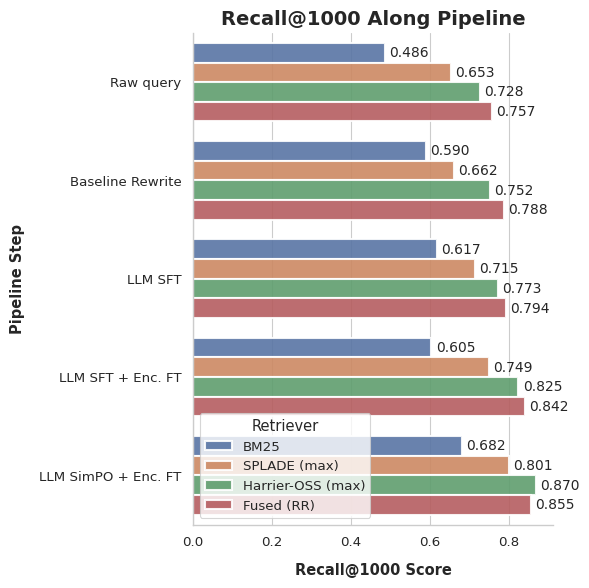

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

DATASET = 'test-2025'
METRICS = ['Success@1000']
STEPS   = ['Raw query', 'Baseline Rewrite', 'LLM SFT', 'LLM SFT + Enc. FT', 'LLM SimPO + Enc. FT']
STEP_DIRS = {
    'Raw query':         agg_raw,
    'Baseline Rewrite':  agg_baseline,
    'LLM SFT':           agg_sft,
    'LLM SFT + Enc. FT':     agg_sft_ast,
    'LLM SimPO + Enc. FT':   agg_simpo,
}

RETRIEVERS = {
    'BM25':               'bm25',
    'SPLADE (max)':       'splade-max',
    'Harrier-OSS (max)':  'dense-medium-max',
    'Fused (RR)':         'fused',
}

rows = []
for step, agg in STEP_DIRS.items():
    df = agg[DATASET].set_index('name')
    for display, key in RETRIEVERS.items():
        for metric in METRICS:
            rows.append({
                'step':      step,
                'retriever': display,
                'metric':    metric,
                'value':     df.loc[key, metric],
            })
long_df = pd.DataFrame(rows)

long_df['step']      = pd.Categorical(long_df['step'],      categories=STEPS,                 ordered=True)
long_df['retriever'] = pd.Categorical(long_df['retriever'], categories=list(RETRIEVERS.keys()),ordered=True)
long_df['metric']    = pd.Categorical(long_df['metric'],    categories=METRICS,               ordered=True)

sns.set_theme(style='whitegrid', context='paper', font_scale=1.1)
PALETTE = sns.color_palette('deep', n_colors=len(RETRIEVERS))

g = sns.catplot(
    data=long_df,
    kind='bar',
    x='value', y='step', hue='retriever',
    col='metric',
    order=STEPS,
    hue_order=list(RETRIEVERS.keys()),
    palette=PALETTE,
    height=6, aspect=1,
    orient='h',
    errorbar=None,
    legend_out=False,
    sharey=True,
    alpha=0.9,
    edgecolor='white',
    linewidth=1.5,
)

# Tighten x-axis to the actual data range so bar-length differences are visible
for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=10, padding=3, rotation=0)
    ax.set_xlabel('Recall@1000 Score', fontweight='bold', labelpad=10)
    ax.set_ylabel('Pipeline Step',     fontweight='bold', labelpad=10)

g.set_titles('Recall@1000 Along Pipeline', size=14, fontweight='bold')
g._legend.set_title('Retriever')
g._legend.set_frame_on(True)
# Put the legend below the plot as a single horizontal row (better for narrow canvas)
g._legend.set_loc('lower left')


plt.tight_layout()
plt.savefig('recallsidebar.pdf')
plt.show()

In [33]:
import numpy as np
from scipy import stats
import ir_measures

# ---- user-editable inputs ----
METRICS_TO_SHOW = [nDCG@10, MRR, Success@1000, nDCG@1000]
DATASET      = 'test-2025'
SIG_TEST     = 'ttest'    # 'wilcoxon' | 'ttest' | 'both'
ALPHA        = 0.05
VS_PREVIOUS  = True           # marker: † (single dagger only)
BOLD_BEST    = True           # bold the best retriever in each (step, metric) row

RETRIEVERS = {
    'BM25'                : 'bm25',
    'SPLADE (max)'        : 'splade-max',
    'SPLADE (top3)'       : 'splade-top3',
    'Harrier-OSS (max)'   : 'dense-medium-max',
    'Harrier-OSS (top3)'  : 'dense-medium-top3',
    'Fused (RR)'          : 'fused',
}

STEPS = ['Raw query', 'Baseline Rewrite', 'LLM SFT',
         'LLM SFT + Enc. FT', 'LLM SimPO + Enc. FT']
RESULTS_BY_STEP = {
    'Raw query'           : raw_results,
    'Baseline Rewrite'    : baseline_rewrite_results,
    'LLM SFT'             : sft_rewrite_results,
    'LLM SFT + Enc. FT'   : sft_ast_results,
    'LLM SimPO + Enc. FT' : simpo_results,
}

# ---- helpers (trimmed) ----
def per_query_metric(res_obj, dataset, rkey, measure):
    run   = res_obj.dt2dfs[dataset][rkey].rename(
        columns={'qid': 'query_id', 'docno': 'doc_id'})
    qrels = res_obj.qrels[dataset].rename(
        columns={'qid': 'query_id', 'docno': 'doc_id'})
    return pd.Series({r.query_id: r.value
                      for r in ir_measures.iter_calc([measure], qrels, run)})

def paired_pvalue(a, b, test='wilcoxon'):
    d = (a - b).dropna()
    if len(d) < 2 or d.abs().sum() == 0:
        return 1.0
    if test == 'ttest':
        _, p = stats.ttest_rel(a, b); return float(p)
    if test == 'wilcoxon':
        try:
            _, p = stats.wilcoxon(a, b); return float(p)
        except ValueError:
            return 1.0
    if test == 'both':
        return min(paired_pvalue(a, b, 'wilcoxon'),
                   paired_pvalue(a, b, 'ttest'))
    raise ValueError(f'unknown test {test!r}')

def fmt_cell(value, mark, bold):
    body = f"{value:.3f}{mark}"
    if bold:
        return r"\textbf{" + body + "}"
    return body

# ---- per-query precompute ----
metric_names = [str(m) for m in METRICS_TO_SHOW]
pq = {}
for step, res_obj in RESULTS_BY_STEP.items():
    for rdisp, rkey in RETRIEVERS.items():
        for m, mname in zip(METRICS_TO_SHOW, metric_names):
            pq[(step, rkey, mname)] = per_query_metric(res_obj, DATASET, rkey, m)

common = pq[next(iter(pq))].index
for s in pq.values():
    common = common.intersection(s.index)
for k in pq:
    pq[k] = pq[k].loc[common]

# ---- build the table (rows = step×metric, cols = retrievers) ----
row_idx = pd.MultiIndex.from_product([STEPS, metric_names],
                                     names=['Pipeline step', 'Metric'])
cells = pd.DataFrame('', index=row_idx, columns=list(RETRIEVERS.keys()))

for mname in metric_names:
    for step in STEPS:
        # find best retriever for this (step, metric)
        if BOLD_BEST:
            best = max(RETRIEVERS,
                       key=lambda rdisp: pq[(step, RETRIEVERS[rdisp], mname)].mean())
        else:
            best = None
        i = STEPS.index(step)
        for rdisp, rkey in RETRIEVERS.items():
            cur = pq[(step, rkey, mname)]
            mk = ''
            if i > 0 and VS_PREVIOUS:
                prev = pq[(STEPS[i-1], rkey, mname)]
                d   = (cur - prev).mean()
                p   = paired_pvalue(cur, prev, SIG_TEST)
                if d > 0 and np.isfinite(p) and p < ALPHA:
                    mk = r"$\dagger$"
            cells.loc[(step, mname), rdisp] = fmt_cell(
                cur.mean(), mk, bold=(rdisp == best))

pipeline_table = cells
pipeline_table

BM25    SPLADE (max)  \
Pipeline step       Metric                                         
Raw query           nDCG@10                0.122           0.165   
                    RR                     0.111           0.149   
                    Success@1000           0.486           0.653   
                    nDCG@1000              0.170           0.230   
Baseline Rewrite    nDCG@10       0.170$\dagger$           0.163   
                    RR            0.156$\dagger$           0.151   
                    Success@1000  0.590$\dagger$           0.662   
                    nDCG@1000     0.226$\dagger$           0.232   
LLM SFT             nDCG@10                0.161           0.183   
                    RR                     0.144           0.169   
                    Success@1000           0.617  0.715$\dagger$   
                    nDCG@1000              0.221  0.256$\dagger$   
LLM SFT + Enc. FT   nDCG@10                0.132  0.219$\dagger$   
                    RR                     0.118  0.199$\dagger$   
                    Success@1000           0.605  0.749$\dagger$   
                    nDCG@1000              0.196  0.289$\dagger$   
LLM SimPO + Enc. FT nDCG@10       0.216$\dagger$  0.282$\dagger$   
                    RR            0.199$\dagger$  0.257$\dagger$   
                    Success@1000  0.682$\dagger$  0.801$\dagger$   
                    nDCG@1000     0.279$\dagger$  0.350$\dagger$   

                                   SPLADE (top3)        Harrier-OSS (max)  \
Pipeline step       Metric                                                  
Raw query           nDCG@10                0.160                    0.198   
                    RR                     0.146                    0.176   
                    Success@1000           0.659                    0.728   
                    nDCG@1000              0.225                    0.269   
Baseline Rewrite    nDCG@10                0.139           0.232$\dagger$   
                    RR                     0.126           0.209$\dagger$   
                    Success@1000           0.675                    0.752   
                    nDCG@1000              0.210           0.302$\dagger$   
LLM SFT             nDCG@10                0.156                    0.237   
                    RR            0.144$\dagger$           \textbf{0.216}   
                    Success@1000  0.727$\dagger$                    0.773   
                    nDCG@1000     0.232$\dagger$                    0.309   
LLM SFT + Enc. FT   nDCG@10       0.183$\dagger$  \textbf{0.276$\dagger$}   
                    RR            0.166$\dagger$  \textbf{0.245$\dagger$}   
                    Success@1000  0.749$\dagger$           0.825$\dagger$   
                    nDCG@1000     0.256$\dagger$  \textbf{0.345$\dagger$}   
LLM SimPO + Enc. FT nDCG@10       0.224$\dagger$  \textbf{0.318$\dagger$}   
                    RR            0.203$\dagger$  \textbf{0.284$\dagger$}   
                    Success@1000  0.797$\dagger$  \textbf{0.870$\dagger$}   
                    nDCG@1000     0.297$\dagger$  \textbf{0.386$\dagger$}   

                                 Harrier-OSS (top3)               Fused (RR)  
Pipeline step       Metric                                                    
Raw query           nDCG@10                   0.167           \textbf{0.221}  
                    RR                        0.146           \textbf{0.201}  
                    Success@1000              0.741           \textbf{0.757}  
                    nDCG@1000                 0.238           \textbf{0.294}  
Baseline Rewrite    nDCG@10          0.194$\dagger$  \textbf{0.238$\dagger$}  
                    RR               0.170$\dagger$           \textbf{0.211}  
                    Success@1000              0.749  \textbf{0.788$\dagger$}  
                    nDCG@1000        0.262$\dagger$  \textbf{0.310$\dagger$}  
LLM SFT             nDCG@10                   0.195           

In [34]:
row_idx = pd.MultiIndex.from_product([metric_names, STEPS],
                                     names=['Metric', 'Pipeline step'])
cells = pd.DataFrame('', index=row_idx, columns=list(RETRIEVERS.keys()))

for mname in metric_names:
    for step in STEPS:
        if BOLD_BEST:
            best = max(RETRIEVERS,
                       key=lambda rdisp: pq[(step, RETRIEVERS[rdisp], mname)].mean())
        else:
            best = None
        i = STEPS.index(step)
        for rdisp, rkey in RETRIEVERS.items():
            cur = pq[(step, rkey, mname)]
            mk = ''
            if i > 0 and VS_PREVIOUS:
                prev = pq[(STEPS[i-1], rkey, mname)]
                d   = (cur - prev).mean()
                p   = paired_pvalue(cur, prev, SIG_TEST)
                if d > 0 and np.isfinite(p) and p < ALPHA:
                    mk = r"$\dagger$"
            cells.loc[(mname, step), rdisp] = fmt_cell(
                cur.mean(), mk, bold=(rdisp == best))

pipeline_table = cells
pipeline_table

BM25    SPLADE (max)  \
Metric       Pipeline step                                         
nDCG@10      Raw query                     0.122           0.165   
             Baseline Rewrite     0.170$\dagger$           0.163   
             LLM SFT                       0.161           0.183   
             LLM SFT + Enc. FT             0.132  0.219$\dagger$   
             LLM SimPO + Enc. FT  0.216$\dagger$  0.282$\dagger$   
RR           Raw query                     0.111           0.149   
             Baseline Rewrite     0.156$\dagger$           0.151   
             LLM SFT                       0.144           0.169   
             LLM SFT + Enc. FT             0.118  0.199$\dagger$   
             LLM SimPO + Enc. FT  0.199$\dagger$  0.257$\dagger$   
Success@1000 Raw query                     0.486           0.653   
             Baseline Rewrite     0.590$\dagger$           0.662   
             LLM SFT                       0.617  0.715$\dagger$   
             LLM SFT + Enc. FT             0.605  0.749$\dagger$   
             LLM SimPO + Enc. FT  0.682$\dagger$  0.801$\dagger$   
nDCG@1000    Raw query                     0.170           0.230   
             Baseline Rewrite     0.226$\dagger$           0.232   
             LLM SFT                       0.221  0.256$\dagger$   
             LLM SFT + Enc. FT             0.196  0.289$\dagger$   
             LLM SimPO + Enc. FT  0.279$\dagger$  0.350$\dagger$   

                                   SPLADE (top3)        Harrier-OSS (max)  \
Metric       Pipeline step                                                  
nDCG@10      Raw query                     0.160                    0.198   
             Baseline Rewrite              0.139           0.232$\dagger$   
             LLM SFT                       0.156                    0.237   
             LLM SFT + Enc. FT    0.183$\dagger$  \textbf{0.276$\dagger$}   
             LLM SimPO + Enc. FT  0.224$\dagger$  \textbf{0.318$\dagger$}   
RR           Raw query                     0.146                    0.176   
             Baseline Rewrite              0.126           0.209$\dagger$   
             LLM SFT              0.144$\dagger$           \textbf{0.216}   
             LLM SFT + Enc. FT    0.166$\dagger$  \textbf{0.245$\dagger$}   
             LLM SimPO + Enc. FT  0.203$\dagger$  \textbf{0.284$\dagger$}   
Success@1000 Raw query                     0.659                    0.728   
             Baseline Rewrite              0.675                    0.752   
             LLM SFT              0.727$\dagger$                    0.773   
             LLM SFT + Enc. FT    0.749$\dagger$           0.825$\dagger$   
             LLM SimPO + Enc. FT  0.797$\dagger$  \textbf{0.870$\dagger$}   
nDCG@1000    Raw query                     0.225                    0.269   
             Baseline Rewrite              0.210           0.302$\dagger$   
             LLM SFT              0.232$\dagger$                    0.309   
             LLM SFT + Enc. FT    0.256$\dagger$  \textbf{0.345$\dagger$}   
             LLM SimPO + Enc. FT  0.297$\dagger$  \textbf{0.386$\dagger$}   

                                 Harrier-OSS (top3)               Fused (RR)  
Metric       Pipeline step                                                    
nDCG@10      Raw query                        0.167           \textbf{0.221}  
             Baseline Rewrite        0.194$\dagger$  \textbf{0.238$\dagger$}  
             LLM SFT                          0.195           \textbf{0.244}  
             LLM SFT + Enc. FT       0.230$\dagger$                    0.242  
             LLM SimPO + Enc. FT     0.268$\dagger$           0.286$\dagger$  
RR           Raw query                        0.146           \textbf{0.201}  
             Baseline Rewrite        0.170$\dagger$           \textbf{0.211}  
             LLM SFT                          0.177                    0.215  
             LLM SFT + Enc. FT       0.208$\dagger$           

In [35]:
caption = ("Pipeline results on %s. " % DATASET +
           "* vs raw-query baseline (p<.05), ** p<.01; "
           r"$\dagger$ vs previous stage (p<.05), $\dagger\dagger$ p<.01. "
           "Bolded cells contain statistically significant increases. "
           f"Paired test: {SIG_TEST}.")
latex = pipeline_table.to_latex(
    escape=False,
    multicolumn_format='c',
    column_format='ll' + 'c' * len(RETRIEVERS),   # 2 label cols + 6 retrievers
    caption=caption,
    label='tab:pipeline',
)
print(latex)


\begin{table}
\caption{Pipeline results on test-2025. * vs raw-query baseline (p<.05), ** p<.01; $\dagger$ vs previous stage (p<.05), $\dagger\dagger$ p<.01. Bolded cells contain statistically significant increases. Paired test: ttest.}
\label{tab:pipeline}
\begin{tabular}{llcccccc}
\toprule
 &  & BM25 & SPLADE (max) & SPLADE (top3) & Harrier-OSS (max) & Harrier-OSS (top3) & Fused (RR) \\
Metric & Pipeline step &  &  &  &  &  &  \\
\midrule
\multirow[t]{5}{*}{nDCG@10} & Raw query & 0.122 & 0.165 & 0.160 & 0.198 & 0.167 & \textbf{0.221} \\
 & Baseline Rewrite & 0.170$\dagger$ & 0.163 & 0.139 & 0.232$\dagger$ & 0.194$\dagger$ & \textbf{0.238$\dagger$} \\
 & LLM SFT & 0.161 & 0.183 & 0.156 & 0.237 & 0.195 & \textbf{0.244} \\
 & LLM SFT + Enc. FT & 0.132 & 0.219$\dagger$ & 0.183$\dagger$ & \textbf{0.276$\dagger$} & 0.230$\dagger$ & 0.242 \\
 & LLM SimPO + Enc. FT & 0.216$\dagger$ & 0.282$\dagger$ & 0.224$\dagger$ & \textbf{0.318$\dagger$} & 0.268$\dagger$ & 0.286$\dagger$ \\
\cline{1-8}
\m

In [15]:
#Lets filter the test-2025 dataset for only synthetic queries
df = pd.read_csv('../queries/test-2025/test-2025-query-mapping.tsv', sep='\t')
fake = df[df['source'] == 'synthetic']
fake['query_id'] = fake['query_id'].astype(str)
fake

/tmp/ipykernel_3984867/1706022964.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fake['query_id'] = fake['query_id'].astype(str)


,query_id,source,llm,domain,rel_doc_id,rel_doc_title,query
0,3000,synthetic,gpt-4o,cheese,26092459,Metton,I remember this certain type of cheese from wa...
4,3004,synthetic,Llama-3.1-8B-Instruct,japanese clan,7341439,Kagawa clan,I vividly remember strolling through the archi...
5,3005,synthetic,gpt-4o,summit meeting,32899075,9th G-15 summit,There was this gathering that I vaguely rememb...
6,3006,synthetic,Llama-3.1-8B-Instruct,enzyme,14023830,10-hydroxydihydrosanguinarine 10-O-methyltrans...,"It's all fuzzy now, but I remember this really..."
7,3007,synthetic,gpt-4o,japanese clan,16546335,Nait clan,There's this old samurai family that's been on...
...,...,...,...,...,...,...,...
616,3616,synthetic,gpt-4o,public transit accident,24749741,Pontypridd railway accident,"There was this story I heard once, possibly fr..."
617,3617,synthetic,gpt-4o,indian constituency,36229253,Sangli Assembly constituency,Somewhere in the western reaches of vibrant In...
618,3618,synthetic,Llama-3.1-8B-Instruct,attraction,6108438,Canada Pavilion at Epcot,"There's this...oh god, I'm really struggling t..."
620,3620,synthetic,Llama-3.1-8B-Instruct,religious building,38133878,Tengku Ampuan Afzan Mosque,I remember walking through a charming small to...


In [ ]:
results = ExperimentResults(get_result_dirs(Path('./raw-query')), DATASETS, '../queries')

TypeError: ExperimentResults.__init__() takes 3 positional arguments but 4 were given

In [4]:
raw_results = ExperimentResults(get_result_dirs(Path('./rewrite-sft-ast')), DATASETS_TO_TEST)
agg_raw = raw_results.aggregate_experiment_results(AGGR_METRICS)

{'sft-train': {'bm25': PosixPath('rewrite-sft-ast/bm25/base-bm25-sft-train-run.csv')}}


NameError: name 'AGGR_METRICS' is not defined

In [ ]:
agg_raw['sft-train']

,name,nDCG@10,nDCG@100,nDCG@1000,Success@1,Success@10,Success@100,Success@1000,RR
0,bm25,0.192842,0.238704,0.25297,0.116,0.2824,0.506,0.6116,0.174227
1,fused,0.192842,0.238704,0.25297,0.116,0.2824,0.506,0.6116,0.174227


In [ ]:
results.qrels['test-2025'] = results.qrels['test-2025'][results.qrels['test-2025']['qid'].isin(fake['query_id'])]
results.queries['test-2025'] = results.queries['test-2025'][results.queries['test-2025']['qid'].isin(fake['query_id'])]

In [ ]:
agg_raw = results.aggregate_experiment_results(AGGR_METRICS)

In [ ]:
agg_raw['test-2025']

,name,nDCG@10,nDCG@100,nDCG@1000,Success@1,Success@10,Success@100,Success@1000,RR
0,bm25,0.107616,0.129055,0.144614,0.063333,0.170000,0.280000,0.406667,0.092911
1,dense-max,0.188570,0.229818,0.253802,0.106667,0.290000,0.496667,0.693333,0.165276
2,dense-top3,0.127986,0.159718,0.200151,0.080000,0.183333,0.340000,0.690000,0.117657
3,splade-max,0.160393,0.204609,0.229726,0.086667,0.240000,0.460000,0.663333,0.144148
4,splade-top3,0.114438,0.143697,0.184671,0.070000,0.163333,0.310000,0.653333,0.105368
5,fused,0.166609,0.218035,0.241207,0.080000,0.270000,0.530000,0.720000,0.144171


In [ ]:
df['domain'].value_counts()

domain
movies                        172
celebrity                      53
movie                          50
landmark                       47
japanese clan                   6
cheese                          6
summit meeting                  6
enzyme                          6
football match                  6
radio show                      6
australian political party      6
artificial fly                  6
networking protocol             6
laboratory equipment            6
economist                       6
eu legislation                  6
referendum                      6
algorithm                       6
cocktail                        6
mathematical statement          6
cpu architecture                6
tribe                           6
court case                      6
gene                            6
religious building              6
encryption method               6
medical condition               6
astronomical event              6
musical scale                   6
diving 

In [ ]:
print(', '.join(df['domain'].unique()))

cheese, movies, movie, landmark, japanese clan, summit meeting, enzyme, radio show, football match, australian political party, artificial fly, networking protocol, celebrity, laboratory equipment, economist, eu legislation, referendum, algorithm, cocktail, mathematical statement, cpu architecture, tribe, court case, gene, religious building, encryption method, medical condition, astronomical event, musical scale, diving equipment, online service, aircraft occurrence, magazine, court, software, molecular geometry, chess opening, musical interval, pinball, buddhist term, attraction, scientist, judo technique, probability distribution, clothing type, financial index, yacht club, film awards, pseudoscience, public transit accident, cloud type, asian comic series, indian constituency, u.s. legislation
